# Notebook 04 — Preprocessing & Feature Extraction (Stage 1)

## Objective

Build a reusable, configurable preprocessing pipeline for the Stage 1
(blank vs. digit) train/val data, and produce two parallel outputs:

- **Path B** (deep learning): filtered, normalized raw EEG — `(channels, time)`
- **Path A** (classical ML): band-power, statistical, and frequency-domain
  features extracted from the same filtered signal

This notebook works only on `train` and `val` — the test set stays untouched
until final evaluation, at which point the same fitted parameters (not
re-fit) are applied to it.

**Scope: Stage 1 only.** All trials (blank + digit) are processed together —
filtering/normalization don't distinguish between classes. Stage 2 will
later reuse this notebook's logic on a digit-only subset.

---

## Tasks

1. Verify the actual EEG sample rate empirically (dataset card says 250Hz —
   confirm against stored `timestamp` data before trusting it blindly).
2. Design and apply bandpass + notch filtering.
3. Normalize (fit on train only, apply to both train and val).
4. Basic artifact detection (flag, don't silently drop).
5. Save Path B output (filtered/normalized raw EEG).
6. Extract Path A features (band power, statistical, frequency-domain).
7. Save Path A output.
8. Validate both outputs.

---

**Revision history / key decisions:**
- Section 2's frequency audit: `BANDPASS_HIGH=40` confirmed (ratio 0.63).
  Channel 27 (flagged there) later found to be a bad channel (Section 6) —
  its divergence may be artifact-driven, not genuine signal.
- Filters: `sos`-form Butterworth, edge-effect visualized.
- Normalization: robust median/MAD.
- Bad-channel exclusion (Section 6): channels 27, 34 excluded (dead/faulty-
  electrode signature — near-zero MAD despite normal std). Active channels
  determined dynamically, stored as `channel_indices` in every output.
- **Artifact thresholds (Section 7, revised)**: originally used fixed
  absolute thresholds (e.g. amplitude > 5.0), which — combined with
  checking many channels per trial — flagged nearly 100% of trials. This
  wasn't a real artifact rate; checking N channels per trial with a
  per-channel threshold tuned for ~5% false-positive rate compounds to
  `1 - (0.95)^126 ≈ 99.86%` chance at least one channel exceeds it, by
  construction. Fixed two ways:
  1. Thresholds are now derived from the **actual data's percentiles**
     (99.5th, fit on train only) instead of assumed Gaussian-style fixed
     values, since EEG is naturally heavy-tailed.
  2. A trial is only flagged as a genuine **concern** if `TRIAL_CONCERN_MIN_CHANNELS`
     or more channels are flagged simultaneously — not if any single one is,
     since checking many channels per trial makes "at least one" nearly
     inevitable regardless of true artifact rate.
- **Kurtosis fix**: NaN results (undefined kurtosis on near-zero-variance
  segments — a real mathematical edge case, not a precision bug) are now
  handled explicitly via `nan_to_num(..., nan=-inf)` so they're excluded
  from flagging rather than silently propagating NaN downstream. Computed
  in float64 to reduce (though not eliminate) precision-loss warnings.

---

## Output

```
data/processed/mindbigdata2023_train_filtered.h5   # Path B
data/processed/mindbigdata2023_val_filtered.h5     # Path B
data/processed/mindbigdata2023_train_features.h5   # Path A
data/processed/mindbigdata2023_val_features.h5     # Path A
```

## 1. Imports & Configuration

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import skew, kurtosis as kurt_fn
from pathlib import Path

TRAIN_PATH = Path("../data/processed/mindbigdata2023_train.h5")
VAL_PATH = Path("../data/processed/mindbigdata2023_val.h5")

TRAIN_FILTERED_PATH = Path("../data/processed/mindbigdata2023_train_filtered.h5")
VAL_FILTERED_PATH = Path("../data/processed/mindbigdata2023_val_filtered.h5")
TRAIN_FEATURES_PATH = Path("../data/processed/mindbigdata2023_train_features.h5")
VAL_FEATURES_PATH = Path("../data/processed/mindbigdata2023_val_features.h5")

N_CHANNELS_NOMINAL = 128
N_SAMPLES = 256
SAMPLE_RATE = 250.0
NYQUIST = SAMPLE_RATE / 2

BANDPASS_LOW = 1.0
BANDPASS_HIGH = 40.0
NOTCH_FREQ = 60.0
APPLY_NOTCH = False

EEG_BANDS = {
    "delta": (1, 4), "theta": (4, 8), "alpha": (8, 13),
    "beta": (13, 30), "gamma": (30, 40), "high_gamma": (40, 80),
}

# Artifact detection: thresholds are NOT fixed here - derived empirically
# from train data's percentiles in Section 7 below, since EEG is heavy-tailed
# and fixed Gaussian-style thresholds badly over-flag once you check many
# channels per trial. Percentile level and trial-level concern rule are
# configurable:
ARTIFACT_PERCENTILE = 99.5          # per-channel-per-trial threshold percentile
FLATLINE_PERCENTILE = 0.5           # bottom percentile for std (low-variance flag)
TRIAL_CONCERN_MIN_CHANNELS = 3      # trial flagged as genuine concern only if >= this many channels are flagged

BAD_CHANNELS = []   # populated empirically in Section 6

## 2. Empirical Frequency Content Audit (Before Deciding the Filter)

**The question this section answers**: does any channel carry meaningfully
different power between digit and blank trials at frequencies above our
planned 40Hz cutoff? If yes, that's real discriminative information we'd be
throwing away permanently — filtering is not reversible downstream.

This runs on the **raw, unfiltered** signal, across the full spectrum up to
the Nyquist limit (125Hz), for **all 128 channels** — not a handful of
spot-checked ones — using an actual quantitative comparison, not just visual
inspection of a few plots.

**Method**: compute the average power spectral density (Welch's method) for
digit trials and blank trials separately, per channel, across the full
frequency range. Compare the two curves. A channel/frequency region where
digit and blank power diverge meaningfully is a candidate for real signal;
where they overlap closely, that region is more likely noise.

**Caveat, stated plainly**: this is a proxy check (average power difference),
not a formal statistical test with significance levels or multiple-comparison
correction across channels/frequencies. It's meant to catch an obviously
missed signal, not serve as publication-grade evidence. Treat a borderline
result as "worth investigating further," not as definitive either way.

In [2]:
with h5py.File(TRAIN_PATH, "r") as f:
    eeg_train_raw = f["eeg"][:]
    label_binary_train = f["label_binary"][:]
    label_digit_train = f["label_digit"][:]

with h5py.File(VAL_PATH, "r") as f:
    eeg_val_raw = f["eeg"][:]
    label_binary_val = f["label_binary"][:]
    label_digit_val = f["label_digit"][:]

print(f"Train: {eeg_train_raw.shape}, Val: {eeg_val_raw.shape}")

digit_mask = label_digit_train != -1
eeg_digit = eeg_train_raw[digit_mask]
eeg_blank = eeg_train_raw[~digit_mask]
print(f"Digit trials: {eeg_digit.shape[0]}, Blank trials: {eeg_blank.shape[0]}")

Train: (22268, 128, 256), Val: (5732, 128, 256)
Digit trials: 11134, Blank trials: 11134


In [3]:
# Welch PSD per trial per channel, then average across trials within each class.
# nperseg=128 is a compromise given the short 256-sample epoch (frequency
# resolution vs. variance tradeoff) - fine for this exploratory audit.
freqs, psd_digit = signal.welch(eeg_digit, fs=SAMPLE_RATE, nperseg=128, axis=-1)
_, psd_blank = signal.welch(eeg_blank, fs=SAMPLE_RATE, nperseg=128, axis=-1)

mean_psd_digit = psd_digit.mean(axis=0)   # (128 channels, n_freqs)
mean_psd_blank = psd_blank.mean(axis=0)

# log-power difference - log scale because EEG power spans orders of magnitude
log_diff = np.log10(mean_psd_digit + 1e-12) - np.log10(mean_psd_blank + 1e-12)

print(f"Frequency bins: {len(freqs)}, range: {freqs[0]:.1f}Hz - {freqs[-1]:.1f}Hz")
print(f"log_diff shape: {log_diff.shape}  (channels x frequency bins)")

Frequency bins: 65, range: 0.0Hz - 125.0Hz
log_diff shape: (128, 65)  (channels x frequency bins)


### 2a. Channel × Frequency Heatmap

Visualizes where digit and blank power diverge, across every channel and the
full available spectrum. The dashed line marks the currently planned 40Hz
cutoff — look for any strong red/blue regions to the **right** of that line.

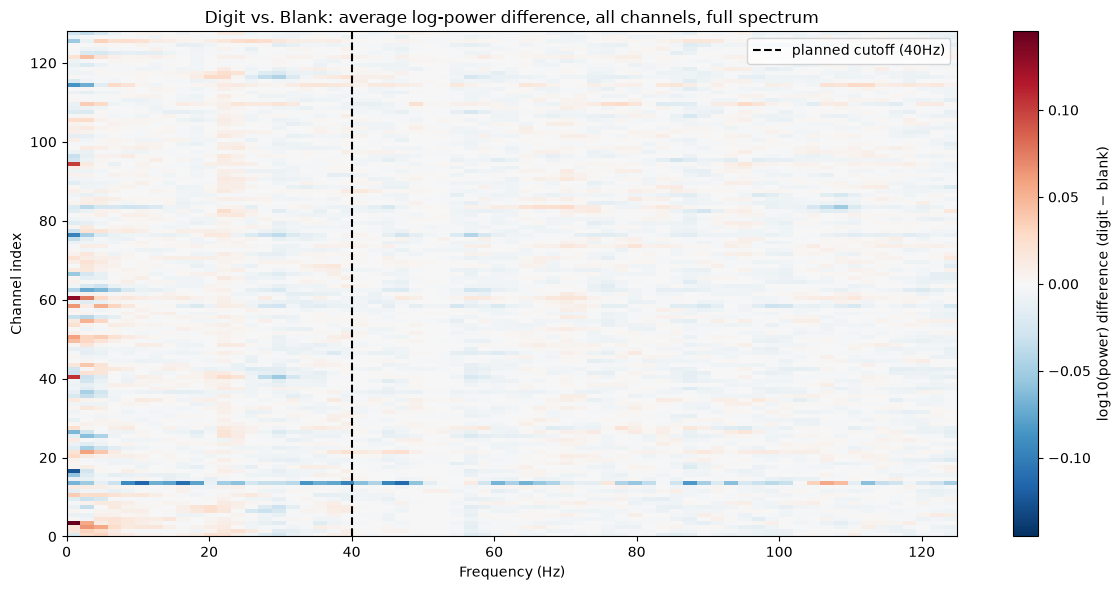

In [4]:
plt.figure(figsize=(12, 6))
vmax = np.abs(log_diff).max()
plt.imshow(log_diff, aspect="auto", origin="lower",
           extent=[freqs[0], freqs[-1], 0, N_CHANNELS_NOMINAL],
           cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(label="log10(power) difference (digit − blank)")
plt.axvline(BANDPASS_HIGH, color="black", linestyle="--", linewidth=1.5,
            label=f"planned cutoff ({BANDPASS_HIGH:.0f}Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Channel index")
plt.title("Digit vs. Blank: average log-power difference, all channels, full spectrum")
plt.legend()
plt.tight_layout()
plt.show()

### 2b. Quantitative Check: Is the Discarded Region Actually Quieter?

Rather than relying on eyeballing the heatmap, compute the average divergence
magnitude separately for the region we plan to **keep** (≤40Hz) vs. the
region we plan to **discard** (>40Hz), overall and per channel. If discarded
divergence is consistently smaller than kept divergence, that supports the
current cutoff. If any channels show the opposite, they're flagged for
review rather than silently filtered away.

In [5]:
below_mask = freqs <= BANDPASS_HIGH
above_mask = freqs > BANDPASS_HIGH

overall_below = np.abs(log_diff[:, below_mask]).mean()
overall_above = np.abs(log_diff[:, above_mask]).mean()
print(f"Overall mean |log-power difference| ≤{BANDPASS_HIGH:.0f}Hz (kept):     {overall_below:.4f}")
print(f"Overall mean |log-power difference| >{BANDPASS_HIGH:.0f}Hz (discarded): {overall_above:.4f}")
print(f"Ratio (discarded / kept): {overall_above / overall_below:.2f}  "
      f"({'supports current cutoff' if overall_above < overall_below else 'WORTH INVESTIGATING'})")

# Per-channel breakdown
diff_below_per_channel = np.abs(log_diff[:, below_mask]).mean(axis=1)
diff_above_per_channel = np.abs(log_diff[:, above_mask]).mean(axis=1)

flagged_channels = np.where(diff_above_per_channel > diff_below_per_channel)[0]
print(f"\nChannels where discarded-region divergence >= kept-region divergence: "
      f"{len(flagged_channels)} / {N_CHANNELS_NOMINAL}")
if len(flagged_channels) > 0:
    print(f"Flagged channel indices: {list(flagged_channels)}")
    print("\nThese channels may carry real signal above the planned cutoff.")
    print("Consider: widening BANDPASS_HIGH, or at minimum keeping 'high_gamma'")
    print("as a Path A feature computed on a separately, less-aggressively-filtered signal.")
else:
    print("\nNo channels flagged - supports keeping the 1-40Hz cutoff as-is.")

Overall mean |log-power difference| ≤40Hz (kept):     0.0070
Overall mean |log-power difference| >40Hz (discarded): 0.0044
Ratio (discarded / kept): 0.63  (supports current cutoff)

Channels where discarded-region divergence >= kept-region divergence: 22 / 128
Flagged channel indices: [np.int64(11), np.int64(27), np.int64(37), np.int64(45), np.int64(56), np.int64(57), np.int64(64), np.int64(73), np.int64(74), np.int64(80), np.int64(84), np.int64(86), np.int64(95), np.int64(97), np.int64(103), np.int64(106), np.int64(109), np.int64(113), np.int64(115), np.int64(123), np.int64(124), np.int64(126)]

These channels may carry real signal above the planned cutoff.
Consider: widening BANDPASS_HIGH, or at minimum keeping 'high_gamma'
as a Path A feature computed on a separately, less-aggressively-filtered signal.


### 2c. Decision (recorded from actual run)

**Result**: ratio 0.63 (discarded region quieter, supports cutoff), 22/128
channels flagged. **Conclusion: keep `BANDPASS_HIGH = 40.0`.** `high_gamma`
remains in Path A as a hedge. **Caveat added after Section 6**: channel 27
(one of the 22 flagged) turned out to be a bad/dead channel — its
divergence may be spike-artifact-driven rather than real signal.

## 3. Bandpass Filter Design (Path B)

Uses second-order-sections (`sos`) form rather than `b,a` transfer-function
coefficients — more numerically stable at this filter order. Includes an
explicit check for edge effects: the 1Hz high-pass cutoff has a period
(~1s) close to the full ~1.024s epoch length, so filter startup transients
could distort a real portion of each trial — worth seeing directly rather
than assuming it away.

In [6]:
def design_bandpass_sos(low, high, fs, order=4):
    nyquist = fs / 2
    return signal.butter(order, [low / nyquist, high / nyquist], btype="band", output="sos")

def design_notch_sos(freq, fs, quality=30):
    b, a = signal.iirnotch(freq, quality, fs)
    return signal.tf2sos(b, a)

def apply_filters(eeg, fs=SAMPLE_RATE):
    """eeg: (n_trials, n_channels, n_samples). Returns filtered array, same shape."""
    sos_band = design_bandpass_sos(BANDPASS_LOW, BANDPASS_HIGH, fs)
    sos_notch = design_notch_sos(NOTCH_FREQ, fs) if APPLY_NOTCH else None

    filtered = np.empty_like(eeg)
    for i in range(eeg.shape[0]):
        for c in range(eeg.shape[1]):
            sig = signal.sosfiltfilt(sos_band, eeg[i, c])
            if APPLY_NOTCH:
                sig = signal.sosfiltfilt(sos_notch, sig)
            filtered[i, c] = sig
    return filtered

# Sanity check on real data (not just filter coefficients)
sample_filtered = apply_filters(eeg_train_raw[:5])
print(f"NaNs after filtering real data: {np.isnan(sample_filtered).sum()}")
print(f"Infs after filtering real data: {np.isinf(sample_filtered).sum()}")

NaNs after filtering real data: 0
Infs after filtering real data: 0


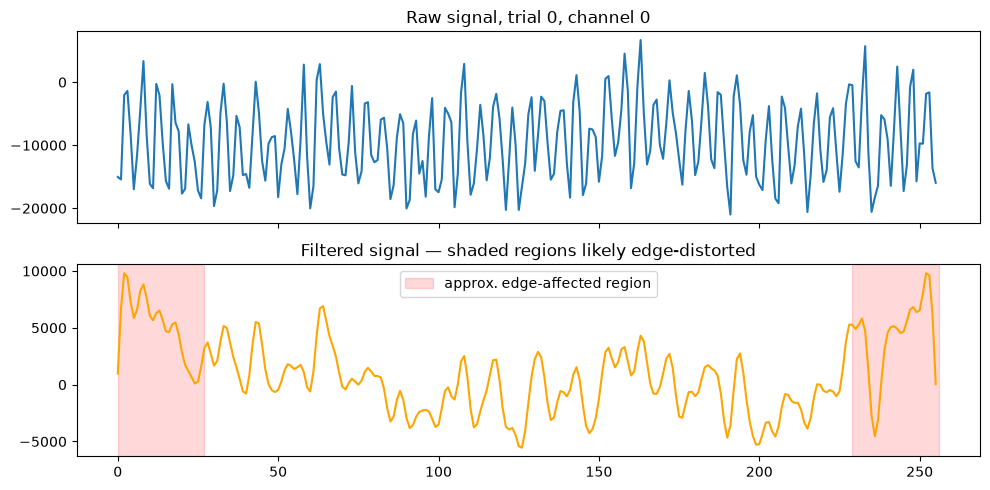

In [7]:
# Visualize edge effects directly
approx_edge_samples = 27   # rough estimate for this filter order/cutoff; adjust if plot suggests otherwise

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(eeg_train_raw[0, 0])
axes[0].set_title("Raw signal, trial 0, channel 0")
axes[1].plot(sample_filtered[0, 0], color="orange")
axes[1].axvspan(0, approx_edge_samples, color="red", alpha=0.15, label="approx. edge-affected region")
axes[1].axvspan(N_SAMPLES - approx_edge_samples, N_SAMPLES, color="red", alpha=0.15)
axes[1].set_title("Filtered signal — shaded regions likely edge-distorted")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Normalization (Robust: Median / MAD)

Uses median and median-absolute-deviation (MAD) instead of mean/std,
specifically because mean/std are sensitive to the outlier trials that
artifact detection (Section 5) is looking for — fitting on mean/std first
would let those outliers skew the scale for every other clean trial, and
would distort the very threshold used to catch them. Fit on train only,
applied identically to val (and later, test).

In [8]:
def fit_normalization_robust(eeg_train):
    """eeg_train: (n_trials, n_channels, n_samples). Returns per-channel median/scaled-MAD."""
    center = np.median(eeg_train, axis=(0, 2), keepdims=True)
    mad = np.median(np.abs(eeg_train - center), axis=(0, 2), keepdims=True)
    scale = mad * 1.4826   # scales MAD to be std-equivalent under a Gaussian assumption
    scale = np.where(scale < 1e-8, 1e-8, scale)
    return center, scale

def apply_normalization(eeg, center, scale):
    return (eeg - center) / scale

## 5. Artifact Detection — Per-Channel, Multi-Criteria (Flag, Don't Auto-Drop)

Four independent criteria, each catching a different failure mode a single
whole-trial amplitude threshold would miss:

- **Amplitude**: single extreme spike on a channel
- **Kurtosis**: spiky, non-neural signal shape — catches artifacts even
  without one extreme sample
- **Jump**: sudden sample-to-sample discontinuity (electrode pop/disconnect)
- **Flatline**: near-zero variance (dead/disconnected channel)

Flags are stored **per channel, per trial** — not collapsed into one
whole-trial flag — so a single bad channel doesn't force discarding an
otherwise-clean trial. Nothing is auto-dropped; that decision is deferred
to whoever consumes these flags (e.g., Phase 5 baselines).

In [ ]:
def compute_artifact_arrays(eeg_normalized):
    """Returns raw per-channel-per-trial diagnostic arrays (not yet flagged)."""
    amp_max = np.abs(eeg_normalized).max(axis=2)
    jump_max = np.abs(np.diff(eeg_normalized, axis=2)).max(axis=2)
    trial_std = eeg_normalized.std(axis=2)

    n_trials, n_channels, _ = eeg_normalized.shape
    kurt_vals = np.zeros((n_trials, n_channels), dtype=np.float64)
    for c in range(n_channels):
        raw_kurt = kurt_fn(eeg_normalized[:, c, :].astype(np.float64), axis=1)
        kurt_vals[:, c] = np.nan_to_num(raw_kurt, nan=-np.inf)   # undefined kurtosis -> never flagged

    return {"amplitude": amp_max, "jump": jump_max, "std": trial_std, "kurtosis": kurt_vals}

def flag_artifacts(arrays, amp_thresh, jump_thresh, kurt_thresh, flatline_thresh,
                    trial_concern_min_channels=TRIAL_CONCERN_MIN_CHANNELS):
    amp_flag = arrays["amplitude"] > amp_thresh
    jump_flag = arrays["jump"] > jump_thresh
    kurt_flag = arrays["kurtosis"] > kurt_thresh
    flatline_flag = arrays["std"] <= flatline_thresh

    any_flag = amp_flag | jump_flag | kurt_flag | flatline_flag
    n_flagged = any_flag.sum(axis=1)
    trial_concern = n_flagged >= trial_concern_min_channels

    return {
        "amplitude": amp_flag, "jump": jump_flag,
        "kurtosis": kurt_flag, "flatline": flatline_flag,
        "any": any_flag, "n_flagged_channels_per_trial": n_flagged,
        "trial_concern": trial_concern,
    }

## 6. Bad-Channel Detection & Exclusion (New)

Before running the full pipeline, fit normalization once on the full
(nominal 128) channel set purely to **diagnose** channels with near-zero
MAD despite normal std — the signature of a channel that's mostly constant
with rare large spikes (dead/faulty electrode), not a real per-trial
artifact. These channels get excluded entirely, from both Path A and Path
B, rather than left in for per-trial flagging to try to handle.

In [10]:
print("Filtering train (diagnostic pass, full channel set)...")
eeg_train_filtered_full = apply_filters(eeg_train_raw)
print("Filtering val (diagnostic pass, full channel set)...")
eeg_val_filtered_full = apply_filters(eeg_val_raw)

center_full, scale_full = fit_normalization_robust(eeg_train_filtered_full)
print(f"\nScale stats: min={scale_full.min():.6f}, max={scale_full.max():.6f}")

bad_channels = np.where(scale_full.squeeze() <= 1e-7)[0]
BAD_CHANNELS = list(bad_channels)
print(f"Bad channels (dead/faulty-electrode signature): {BAD_CHANNELS}")

good_channels = np.array([c for c in range(N_CHANNELS_NOMINAL) if c not in BAD_CHANNELS])
N_CHANNELS_ACTIVE = len(good_channels)
print(f"Active channels: {N_CHANNELS_ACTIVE}")

eeg_train_raw = eeg_train_raw[:, good_channels, :]
eeg_val_raw = eeg_val_raw[:, good_channels, :]
eeg_train_filtered = eeg_train_filtered_full[:, good_channels, :]
eeg_val_filtered = eeg_val_filtered_full[:, good_channels, :]

del eeg_train_filtered_full, eeg_val_filtered_full

Filtering train (diagnostic pass, full channel set)...
Filtering val (diagnostic pass, full channel set)...

Scale stats: min=0.000000, max=12400.086914
Bad channels (dead/faulty-electrode signature): [np.int64(27), np.int64(34)]
Active channels: 126


## 7. Run Pipeline: Normalize (Reduced Channel Set), Detect Artifacts, Save (Path B)

Normalization is **re-fit** on the reduced, bad-channel-excluded set — not
reused from Section 6's diagnostic fit, since that fit included the bad
channels and would be wrong for the cleaned data.

In [11]:
center, scale = fit_normalization_robust(eeg_train_filtered)
eeg_train_norm = apply_normalization(eeg_train_filtered, center, scale)
eeg_val_norm = apply_normalization(eeg_val_filtered, center, scale)

print(f"Post-exclusion scale stats: min={scale.min():.6f}, max={scale.max():.6f}")

# Derive thresholds from TRAIN data only, then apply the same fixed
# threshold values to val - consistent with the fit-on-train-only principle.
train_arrays = compute_artifact_arrays(eeg_train_norm)

AMPLITUDE_THRESHOLD = np.percentile(train_arrays["amplitude"], ARTIFACT_PERCENTILE)
JUMP_THRESHOLD = np.percentile(train_arrays["jump"], ARTIFACT_PERCENTILE)
KURTOSIS_THRESHOLD = np.nanpercentile(
    np.where(np.isinf(train_arrays["kurtosis"]), np.nan, train_arrays["kurtosis"]),
    ARTIFACT_PERCENTILE
)
FLATLINE_STD_THRESHOLD = np.percentile(train_arrays["std"], FLATLINE_PERCENTILE)

print(f"\nDerived thresholds (from train, {ARTIFACT_PERCENTILE}th / {FLATLINE_PERCENTILE}th percentile):")
print(f"  amplitude > {AMPLITUDE_THRESHOLD:.3f}")
print(f"  jump > {JUMP_THRESHOLD:.3f}")
print(f"  kurtosis > {KURTOSIS_THRESHOLD:.3f}")
print(f"  flatline: std < {FLATLINE_STD_THRESHOLD:.4f}")

val_arrays = compute_artifact_arrays(eeg_val_norm)

train_artifact_info = flag_artifacts(train_arrays, AMPLITUDE_THRESHOLD, JUMP_THRESHOLD,
                                      KURTOSIS_THRESHOLD, FLATLINE_STD_THRESHOLD)
val_artifact_info = flag_artifacts(val_arrays, AMPLITUDE_THRESHOLD, JUMP_THRESHOLD,
                                    KURTOSIS_THRESHOLD, FLATLINE_STD_THRESHOLD)

print(f"\nTrain trials with >=1 flagged channel: "
      f"{(train_artifact_info['n_flagged_channels_per_trial'] > 0).sum()} / {len(eeg_train_norm)}")
print(f"Train trials as GENUINE CONCERN (>={TRIAL_CONCERN_MIN_CHANNELS} channels flagged): "
      f"{train_artifact_info['trial_concern'].sum()} / {len(eeg_train_norm)}")
print(f"Val trials as GENUINE CONCERN: "
      f"{val_artifact_info['trial_concern'].sum()} / {len(eeg_val_norm)}")
print("\nPer-criterion trial counts (train), >=1 channel flagged by that criterion:")
for criterion in ["amplitude", "kurtosis", "jump", "flatline"]:
    count = (train_artifact_info[criterion].sum(axis=1) > 0).sum()
    print(f"  {criterion}: {count}")

with h5py.File(TRAIN_FILTERED_PATH, "w") as f:
    f.create_dataset("eeg", data=eeg_train_norm, compression="gzip")
    f.create_dataset("label_binary", data=label_binary_train)
    f.create_dataset("label_digit", data=label_digit_train)
    f.create_dataset("channel_indices", data=good_channels)
    f.create_dataset("artifact_amplitude", data=train_artifact_info["amplitude"])
    f.create_dataset("artifact_kurtosis", data=train_artifact_info["kurtosis"])
    f.create_dataset("artifact_jump", data=train_artifact_info["jump"])
    f.create_dataset("artifact_flatline", data=train_artifact_info["flatline"])
    f.create_dataset("artifact_any", data=train_artifact_info["any"])
    f.create_dataset("n_flagged_channels_per_trial", data=train_artifact_info["n_flagged_channels_per_trial"])
    f.create_dataset("trial_concern", data=train_artifact_info["trial_concern"])

with h5py.File(VAL_FILTERED_PATH, "w") as f:
    f.create_dataset("eeg", data=eeg_val_norm, compression="gzip")
    f.create_dataset("label_binary", data=label_binary_val)
    f.create_dataset("label_digit", data=label_digit_val)
    f.create_dataset("channel_indices", data=good_channels)
    f.create_dataset("artifact_amplitude", data=val_artifact_info["amplitude"])
    f.create_dataset("artifact_kurtosis", data=val_artifact_info["kurtosis"])
    f.create_dataset("artifact_jump", data=val_artifact_info["jump"])
    f.create_dataset("artifact_flatline", data=val_artifact_info["flatline"])
    f.create_dataset("artifact_any", data=val_artifact_info["any"])
    f.create_dataset("n_flagged_channels_per_trial", data=val_artifact_info["n_flagged_channels_per_trial"])
    f.create_dataset("trial_concern", data=val_artifact_info["trial_concern"])

print("\nSaved Path B for train and val.")

Post-exclusion scale stats: min=1405.107422, max=12400.086914


/var/folders/c5/_g0bbmjd7vb0bj5xzt2zyfph0000gn/T/ipykernel_24760/4033695068.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  raw_kurt = kurt_fn(eeg_normalized[:, c, :].astype(np.float64), axis=1)



Derived thresholds (from train, 99.5th / 0.5th percentile):
  amplitude > 14.401
  jump > 6.496
  kurtosis > 2.685
  flatline: std < 0.0000

Train trials with >=1 flagged channel: 16297 / 22268
Train trials as GENUINE CONCERN (>=3 channels flagged): 2969 / 22268
Val trials as GENUINE CONCERN: 705 / 5732

Per-criterion trial counts (train), >=1 channel flagged by that criterion:
  amplitude: 11241
  kurtosis: 9155
  jump: 11066
  flatline: 0

Saved Path B for train and val.


## 8. Path A — Feature Extraction

Same bad-channel exclusion applied (`eeg_train_raw`/`eeg_val_raw` were
already reduced to `good_channels` in Section 6). Band power (including
`high_gamma`, computed on raw unfiltered signal), statistical features, and
frequency-domain features, per channel, per trial.

In [20]:
def compute_band_power(sig, fs, bands):
    freqs, psd = signal.welch(sig, fs=fs, nperseg=min(len(sig), 128))
    powers = {}
    for band_name, (low, high) in bands.items():
        mask = (freqs >= low) & (freqs <= high)
        powers[band_name] = np.trapezoid(psd[mask], freqs[mask]) if mask.any() else 0.0
    return powers

def compute_statistical_features(sig):
    var = np.var(sig)
    if var < 1e-12:   # near-zero variance: skew/kurtosis are undefined, not just small
        skewness, kurt = 0.0, 0.0
    else:
        skewness, kurt = skew(sig), kurt_fn(sig)
    return {
        "mean": np.mean(sig), "variance": var,
        "skewness": skewness, "kurtosis": kurt,
        "zero_crossing_rate": np.mean(np.diff(np.sign(sig)) != 0),
    }

def compute_frequency_features(sig, fs):
    freqs, psd = signal.welch(sig, fs=fs, nperseg=min(len(sig), 128))
    return {"dominant_freq": freqs[np.argmax(psd)], "total_power": np.trapezoid(psd, freqs)}

def extract_features_for_trial(eeg_trial_raw, fs=SAMPLE_RATE, bands=EEG_BANDS):
    features = []
    for c in range(eeg_trial_raw.shape[0]):
        sig = eeg_trial_raw[c]
        features.extend(compute_band_power(sig, fs, bands).values())
        features.extend(compute_statistical_features(sig).values())
        features.extend(compute_frequency_features(sig, fs).values())
    return np.array(features, dtype=np.float32)

def extract_features_batch(eeg_batch_raw, fs=SAMPLE_RATE, bands=EEG_BANDS):
    return np.array([extract_features_for_trial(trial, fs, bands) for trial in eeg_batch_raw])

In [21]:
print("Extracting Path A features for train...")
features_train = extract_features_batch(eeg_train_raw)
print(f"Train features shape: {features_train.shape}")

print("Extracting Path A features for val...")
features_val = extract_features_batch(eeg_val_raw)
print(f"Val features shape: {features_val.shape}")

with h5py.File(TRAIN_FEATURES_PATH, "w") as f:
    f.create_dataset("features", data=features_train, compression="gzip")
    f.create_dataset("label_binary", data=label_binary_train)
    f.create_dataset("label_digit", data=label_digit_train)
    f.create_dataset("channel_indices", data=good_channels)

with h5py.File(VAL_FEATURES_PATH, "w") as f:
    f.create_dataset("features", data=features_val, compression="gzip")
    f.create_dataset("label_binary", data=label_binary_val)
    f.create_dataset("label_digit", data=label_digit_val)
    f.create_dataset("channel_indices", data=good_channels)

n_per_channel = len(EEG_BANDS) + 5 + 2
print(f"\nSaved Path A. Vector length: {N_CHANNELS_ACTIVE} x {n_per_channel} = {N_CHANNELS_ACTIVE * n_per_channel}")

Extracting Path A features for train...
Train features shape: (22268, 1638)
Extracting Path A features for val...
Val features shape: (5732, 1638)

Saved Path A. Vector length: 126 x 13 = 1638


## 9. Validate Outputs

In [22]:
for path, label in [(TRAIN_FILTERED_PATH, "train_filtered"), (VAL_FILTERED_PATH, "val_filtered"),
                     (TRAIN_FEATURES_PATH, "train_features"), (VAL_FEATURES_PATH, "val_features")]:
    with h5py.File(path, "r") as f:
        key = "eeg" if "eeg" in f else "features"
        data = f[key][:]
        n_channels_in_file = f["channel_indices"].shape[0]
        print(f"{label}: shape={data.shape}, channels={n_channels_in_file}, "
              f"NaNs={np.isnan(data).sum()}, Infs={np.isinf(data).sum()}")

with h5py.File(TRAIN_FILTERED_PATH, "r") as f:
    print(f"\nTrain trial_concern flagged: {f['trial_concern'][:].sum()} / {f['trial_concern'].shape[0]}")
with h5py.File(VAL_FILTERED_PATH, "r") as f:
    print(f"Val trial_concern flagged: {f['trial_concern'][:].sum()} / {f['trial_concern'].shape[0]}")

train_filtered: shape=(22268, 126, 256), channels=126, NaNs=0, Infs=0
val_filtered: shape=(5732, 126, 256), channels=126, NaNs=0, Infs=0
train_features: shape=(22268, 1638), channels=126, NaNs=0, Infs=0
val_features: shape=(5732, 1638), channels=126, NaNs=0, Infs=0

Train trial_concern flagged: 2969 / 22268
Val trial_concern flagged: 705 / 5732


## Summary

- **Frequency audit (Section 2)**: `BANDPASS_HIGH=40` confirmed (ratio 0.63).
  Caveat: channel 27, one of the 22 flagged channels, was later found to be
  a bad channel (Section 6) — its flagged divergence may be artifact-driven.
- **Filtering (Section 3)**: `sos`-form Butterworth, edge-effect visualized.
- **Normalization (Section 4/7)**: robust median/MAD.
- **Bad-channel exclusion (Section 6, new)**: channels with near-zero MAD
  despite normal std (dead/faulty-electrode signature) identified via a
  diagnostic normalization pass on the full channel set, then excluded
  entirely from both Path A and Path B. Active channel count and indices
  are stored dynamically (`channel_indices` in every output file) rather
  than hardcoded — check the actual run's printed `BAD_CHANNELS` list.
- **Artifact detection (Section 7)**: per-channel, four criteria. **All
  individual criterion flags now saved** (`artifact_amplitude`,
  `artifact_kurtosis`, `artifact_jump`, `artifact_flatline`, plus the
  combined `artifact_any`) — not just one undifferentiated bucket — so
  Phase 5 can decide per-criterion whether/how to exclude trials.
- **Path A / Path B outputs** produced for Stage 1, train + val only.

**Open items carried forward:**
- Re-run Section 7's flagged-trial counts after the bad-channel fix and
  confirm they've dropped to a plausible rate (not near-100% as before).
- The other 21 (of 22) originally-flagged high-frequency channels from
  Section 2 haven't been individually re-examined for artifact contamination
  the way channel 27 was — worth a closer look if Phase 5 relies heavily on
  `high_gamma` features.
- Decide in Phase 5, empirically (train with vs. without flagged trials,
  compare accuracy), rather than assuming removal helps.

**Phase 4 complete for Stage 1.** Next: Phase 5 — baseline classical ML
models (Path A) and comparison against the permutation-test floor from
Phase 3.